In [12]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


## Part 1: Load and Explore the Dataset

### Load the dataset in Python.
### Print the shape of the training data, test data, and the number of classes.

In [11]:
import numpy as np 
import matplotlib.pyplot as plt 
from tensorflow.keras.datasets  import fashion_mnist 

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data() 

print("x_train shape:", x_train.shape) 
print("y_train shape:", y_train.shape) 
print("x_test shape :", x_test.shape) 
print("y_test shape :", y_test.shape) 

class_names = [ 'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'] 

print("Number of classes:", len(class_names))

x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape : (10000, 28, 28)
y_test shape : (10000,)
Number of classes: 10


### Display at least one sample image from each class.

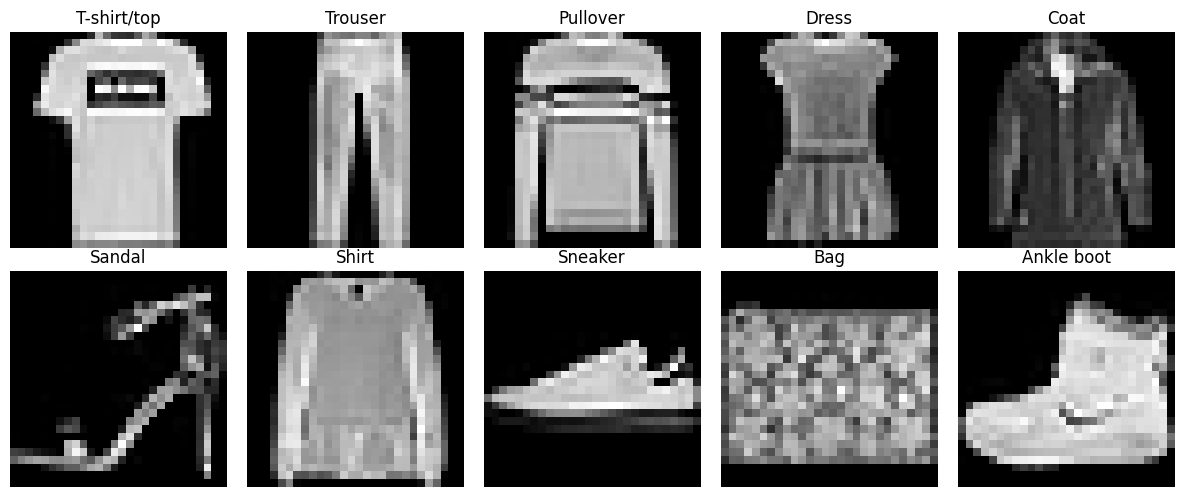

In [8]:
plt.figure(figsize=(12, 5))

for class_id in range(10):
    # index of the first training image belonging to this class
    idx = np.where(y_train == class_id)[0][0]

    plt.subplot(2, 5, class_id + 1)
    plt.imshow(x_train[idx], cmap='gray')
    plt.title(class_names[class_id])
    plt.axis('off')

plt.tight_layout()
plt.show()

### Normalize the image pixel values.

In [5]:
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32') / 255.0

print("Min pixel value:", x_train.min())
print("Max pixel value:", x_train.max())

Min pixel value: 0.0
Max pixel value: 1.0


### Reshape the images appropriately for CNN input.

In [6]:
x_train = x_train.reshape(-1, 28, 28, 1)
x_test  = x_test.reshape(-1, 28, 28, 1)

print("x_train reshaped:", x_train.shape)   # (60000, 28, 28, 1)
print("x_test reshaped :", x_test.shape)     # (10000, 28, 28, 1)

x_train reshaped: (60000, 28, 28, 1)
x_test reshaped : (10000, 28, 28, 1)


### Why is normalization required for image data?
Ans. Raw pixel values range from 0 to 255. Feeding such large values into a network makes training unstable and slow: the weighted sums going into each neuron become large, gradients can swing wildly or blow up, and gradient descent takes longer to converge. Scaling everything to 0–1 keeps the inputs in a small, consistent range, which produces smaller and more uniform gradients, helps the optimizer converge faster and more reliably, and prevents features with large raw magnitudes from dominating the learning. It also pairs well with common weight-initialization schemes, which assume roughly small, centered inputs.

### Why do CNNs require reshaped image inputs?
A 2D convolution layer slides filters across spatial dimensions and needs to know how many channels each pixel has, so it expects a 4D input of the form (batch, height, width, channels). The dataset loads as (60000, 28, 28) — it carries the batch, height, and width but the channel dimension is implicit. Because the images are grayscale, that channel count is 1, and we have to make it explicit by reshaping to (60000, 28, 28, 1). (Color images would already carry a 3 there for RGB.) Without this dimension the Conv2D layer can't interpret the input and will raise a shape error.

## Part 2: Build and Train a Shallow CNN

In [13]:
import time
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

shallow_cnn = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

shallow_cnn.summary()

/opt/homebrew/Cellar/jupyterlab/4.4.9/libexec/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       346,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,146 (1.32 MB)

 Trainable params: 347,146 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

### Compiling the model.

In [14]:
shallow_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### Training the model

In [15]:
start_time = time.time()

history_shallow = shallow_cnn.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=64
)

shallow_training_time = time.time() - start_time
print(f"Shallow CNN training time: {shallow_training_time:.2f} seconds")

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8110 - loss: 1.2732 - val_accuracy: 0.8700 - val_loss: 0.3889
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8805 - loss: 0.3385 - val_accuracy: 0.8843 - val_loss: 0.3330
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8974 - loss: 0.2806 - val_accuracy: 0.8868 - val_loss: 0.3359
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9085 - loss: 0.2458 - val_accuracy: 0.8842 - val_loss: 0.3235
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9179 - loss: 0.2228 - val_accuracy: 0.8877 - val_loss: 0.3318
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9215 - loss: 0.2128 - val_accuracy: 0.8895 - val_loss: 0.3326
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9273 - loss: 0.1949 - val_accuracy: 0.8917 - val_loss: 0.3517
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9334 - loss: 0.1822 - val_accuracy: 0.

### Evaluation

In [16]:
test_loss, test_acc = shallow_cnn.evaluate(x_test, y_test)
print(f"Shallow CNN Test Accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 916us/step - accuracy: 0.8945 - loss: 0.3661
Shallow CNN Test Accuracy: 0.8945


### Plot Curves

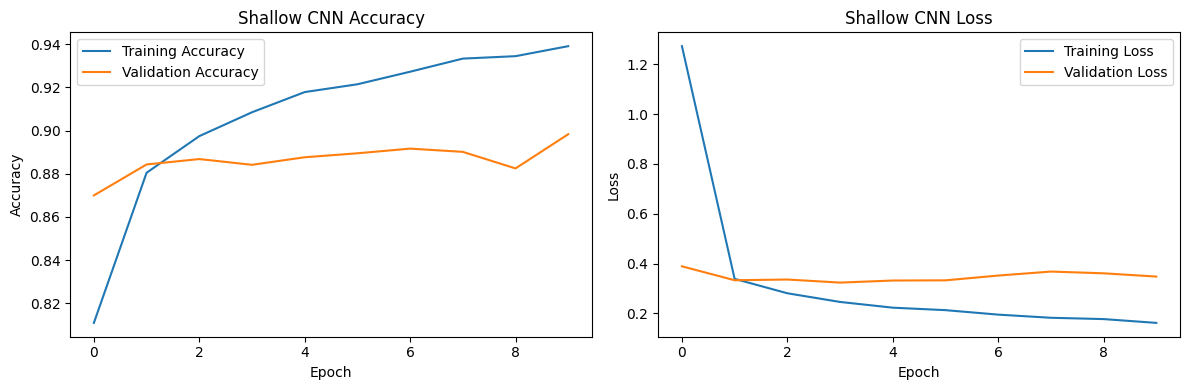

In [17]:
plt.figure(figsize=(12, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history_shallow.history['accuracy'], label='Training Accuracy')
plt.plot(history_shallow.history['val_accuracy'], label='Validation Accuracy')
plt.title('Shallow CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history_shallow.history['loss'], label='Training Loss')
plt.plot(history_shallow.history['val_loss'], label='Validation Loss')
plt.title('Shallow CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

### What kind of patterns do you expect a shallow CNN to learn?
With just one convolution layer, the shallow CNN learns only low-level visual features — edges, simple curves, corners, and basic light/dark contrasts. The single dense layer then combines these to make a class decision. It can pick up the broad outline of an item but can't build richer, higher-level concepts (like recognizing a collar or sleeve structure), since that needs more stacked convolution layers.

### Did the model show signs of underfitting or overfitting?
Mild overfitting. By the final epochs, training accuracy climbs to about 0.94 while validation accuracy plateaus near 0.89–0.90, opening a gap of roughly 4–5 points. The loss plot confirms it: training loss keeps falling toward ~0.15, but validation loss flattens around 0.33–0.34 and stops improving (even ticking up slightly around epoch 7). This pattern — training still improving while validation stalls — means the model is starting to memorize the training data rather than generalize. It isn't severe, though; the validation curve stays stable rather than collapsing, so the model still generalizes reasonably well. There are no signs of underfitting, since both accuracies are high and the training metrics clearly improve over time.

## Part 3: Build and Train a Deep CNN

Conv2D (32 filters) → learns simple features <br>
Conv2D (64 filters) → builds on those into slightly richer features <br>
MaxPooling2D → shrinks the map <br>
Conv2D (128 filters) → learns higher-level patterns <br>
MaxPooling2D → shrinks again <br>
Flatten <br>
Dense (128) → reasoning layer <br>
Dropout → helps prevent overfitting <br>
Dense (10, output)

In [18]:
import time
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

deep_cnn = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

deep_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896,906 (3.42 MB)

 Trainable params: 896,906 (3.42 MB)

 Non-trainable params: 0 (0.00 B)

### Compiling and training

In [19]:
deep_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

start_time = time.time()

history_deep = deep_cnn.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=64
)

deep_training_time = time.time() - start_time
print(f"Deep CNN training time: {deep_training_time:.2f} seconds")

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 30s 35ms/step - accuracy: 0.8217 - loss: 0.5927 - val_accuracy: 0.8805 - val_loss: 0.3298
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 30s 35ms/step - accuracy: 0.8823 - loss: 0.3241 - val_accuracy: 0.8907 - val_loss: 0.2901
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 29s 35ms/step - accuracy: 0.8983 - loss: 0.2792 - val_accuracy: 0.9082 - val_loss: 0.2484
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 29s 35ms/step - accuracy: 0.9090 - loss: 0.2472 - val_accuracy: 0.9055 - val_loss: 0.2498
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 30s 36ms/step - accuracy: 0.9186 - loss: 0.2227 - val_accuracy: 0.9133 - val_loss: 0.2434
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 30s 35ms/step - accuracy: 0.9233 - loss: 0.2046 - val_accuracy: 0.9085 - val_loss: 0.2519
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 30s 35ms/step - accuracy: 0.9290 - loss: 0.1890 - val_accuracy: 0.9127 - val_loss: 0.2535
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 29s 35ms/step - accuracy: 0.9322 - loss: 0.1796 - 

### Evaluating on the test set

In [20]:
test_loss, test_acc = deep_cnn.evaluate(x_test, y_test)
print(f"Deep CNN Test Accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9112 - loss: 0.2819
Deep CNN Test Accuracy: 0.9112


### Plot Curves

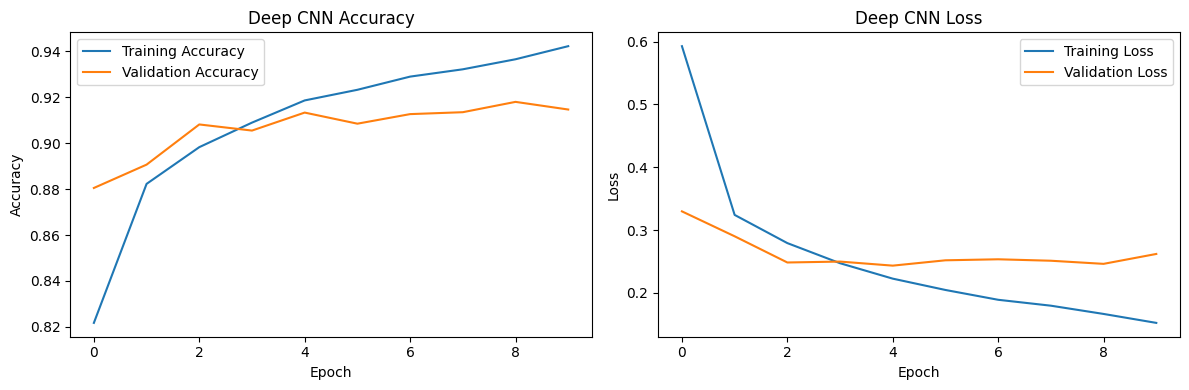

In [21]:
plt.figure(figsize=(12, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history_deep.history['accuracy'], label='Training Accuracy')
plt.plot(history_deep.history['val_accuracy'], label='Validation Accuracy')
plt.title('Deep CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history_deep.history['loss'], label='Training Loss')
plt.plot(history_deep.history['val_loss'], label='Validation Loss')
plt.title('Deep CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

### What additional patterns or representations might a deep CNN learn?
With three stacked convolution layers, the deep CNN learns a hierarchy of features. The early layers still detect simple edges and curves, but the deeper layers combine these into more complex, meaningful shapes — textures, contours, and garment parts like collars, sleeves, shoe soles, or bag straps. These higher-level representations let it distinguish visually similar classes (shirt vs. coat vs. pullover) better than the shallow model could.

### Did the deeper model improve performance meaningfully?
Yes, modestly. Validation accuracy reached about 0.915–0.918, up from the shallow model's ~0.90, so roughly a 1.5–2 point gain. The deeper model also overfit less: its training–validation accuracy gap at the final epoch is only about 2.5–3 points (training ~0.94, validation ~0.915), compared to the shallow model's wider ~4–5 point gap — the Dropout layer helped here. The loss plot confirms this; validation loss settles low around 0.245–0.26 with only a slight upward drift at the end, showing controlled, mild overfitting rather than severe memorization. So the extra depth genuinely improved both accuracy and generalization, though the accuracy gain itself is small on a dataset this simple 

## Part 4: Comparative Study of Shallow CNN vs Deep CNN

In [24]:
# Total parameters
print("Shallow CNN parameters:", shallow_cnn.count_params())
print("Deep CNN parameters   :", deep_cnn.count_params())

# Final-epoch training and validation accuracy
print("Shallow - train acc:", history_shallow.history['accuracy'][-1])
print("Shallow - val acc  :", history_shallow.history['val_accuracy'][-1])
print("Deep    - train acc:", history_deep.history['accuracy'][-1])
print("Deep    - val acc  :", history_deep.history['val_accuracy'][-1])

# Test accuracy (re-run evaluate if you didn't save it)
shallow_test_loss, shallow_test_acc = shallow_cnn.evaluate(x_test, y_test, verbose=0)
deep_test_loss, deep_test_acc = deep_cnn.evaluate(x_test, y_test, verbose=0)
print("Shallow test acc:", shallow_test_acc)
print("Deep test acc   :", deep_test_acc)

# Training times — these are the variables you set in Parts 2 and 3
print("Shallow training time:", shallow_training_time)
print("Deep training time   :", deep_training_time)

Shallow CNN parameters: 347146
Deep CNN parameters   : 896906
Shallow - train acc: 0.9391111135482788
Shallow - val acc  : 0.8983333110809326
Deep    - train acc: 0.9422592520713806
Deep    - val acc  : 0.9146666526794434
Shallow test acc: 0.8945000171661377
Deep test acc   : 0.9111999869346619
Shallow training time: 29.686681032180786
Deep training time   : 298.54898619651794


### Comparison of Shallow CNN and Deep CNN

| Metric | Shallow CNN | Deep CNN |
|---------|------------|----------|
| Number of Conv Layers | 1 | 3 |
| Total Parameters | 347,146 | 896,906 |
| Training Accuracy | 93.91% | 94.23% |
| Validation Accuracy | 89.83% | 91.47% |
| Test Accuracy | 89.45% | 91.11% |
| Overfitting Observed? | Mild (gap ≈ 4.1%) | Mild, less (gap ≈ 2.8%) |
| Training Time | 29.68 | 298.54 |

### Which model performed better overall?
The deep CNN. It scored higher on every accuracy measure — validation 91.47% vs 89.83%, and test 91.11% vs 89.45% — while also overfitting less. On pure performance, the deep model is the clear winner.

### Did the deep CNN justify its added complexity?
Not really, on this dataset. It used about 2.6× more parameters (896,906 vs 347,146) and took roughly 10× longer to train (298.54s vs 29.68s), yet delivered only about a 1.7-point gain in test accuracy (91.11% vs 89.45%). That's a steep cost for a small return — a clear case of diminishing returns. The complexity is justified only if that extra accuracy is critical; for most practical purposes on Fashion-MNIST, it isn't worth the 10× training cost.

### Which model generalized better?
The deep CNN. Its training–validation accuracy gap was smaller (≈2.8% vs ≈4.1%), meaning the difference between what it learned and how it performed on unseen data was tighter. The Dropout layer in the deep model is the main reason — it curbed memorization and helped the model generalize more reliably.

### What trade-off did you observe between simplicity and performance?
A sharp efficiency-versus-accuracy trade-off. The shallow CNN is far simpler and trains about 10× faster with a third of the parameters, sacrificing only ~1.7 points of test accuracy and showing slightly more overfitting. The deep CNN buys higher accuracy and better generalization but pays heavily in parameters, training time, and compute. In short, a large jump in complexity bought only a small improvement in results — so the right choice depends entirely on whether you prioritize speed and simplicity or peak accuracy.

## Part 5: Prediction and Error Analysis

### Generate predictions for both models

In [28]:
import numpy as np

# Each model outputs 10 probabilities per image; pick the highest as the prediction
shallow_pred = np.argmax(shallow_cnn.predict(x_test), axis=1)
deep_pred    = np.argmax(deep_cnn.predict(x_test), axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 901us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


### Show 5 correct and 5 incorrect images for each model

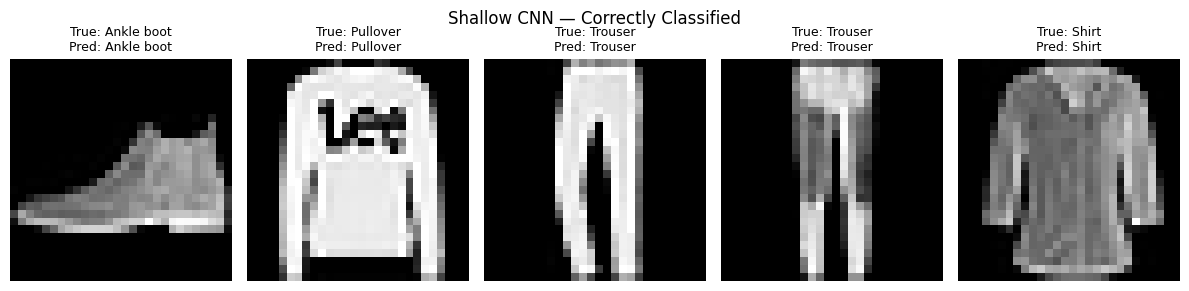

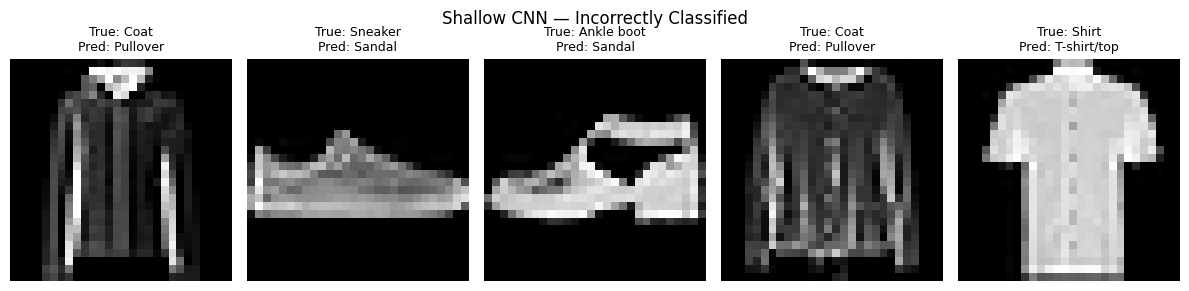

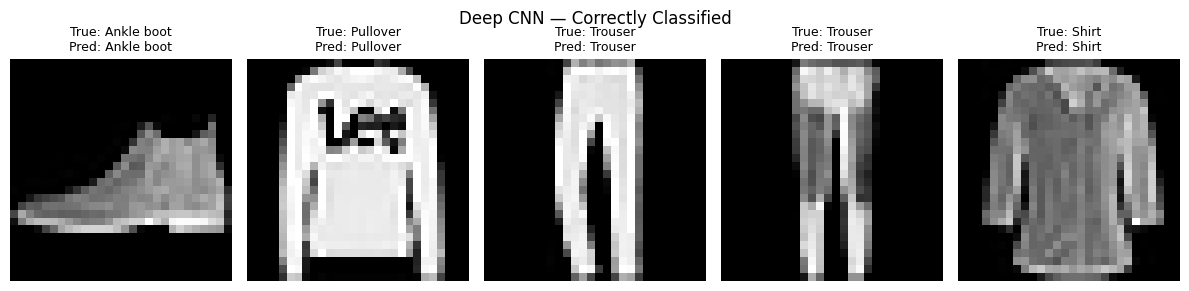

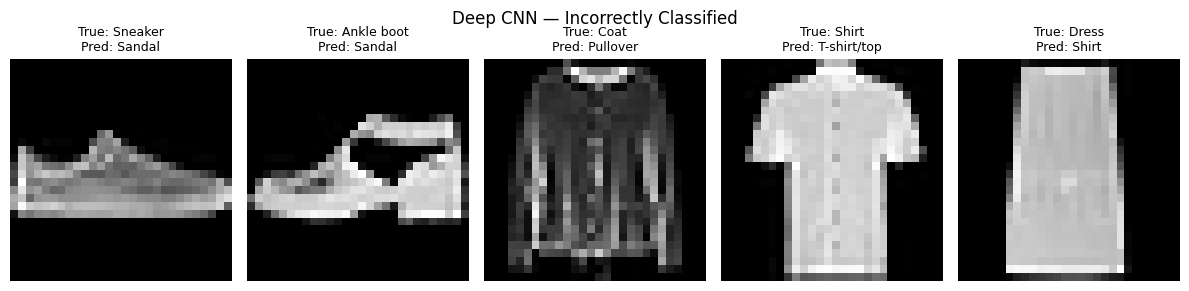

In [29]:
def show_predictions(model_name, predictions, num=5):
    correct_idx   = np.where(predictions == y_test)[0]
    incorrect_idx = np.where(predictions != y_test)[0]

    # 5 correctly classified
    plt.figure(figsize=(12, 3))
    for i in range(num):
        idx = correct_idx[i]
        plt.subplot(1, num, i + 1)
        plt.imshow(x_test[idx].reshape(28, 28), cmap='gray')
        plt.title(f"True: {class_names[y_test[idx]]}\nPred: {class_names[predictions[idx]]}",
                  fontsize=9)
        plt.axis('off')
    plt.suptitle(f"{model_name} — Correctly Classified")
    plt.tight_layout()
    plt.show()

    # 5 incorrectly classified
    plt.figure(figsize=(12, 3))
    for i in range(num):
        idx = incorrect_idx[i]
        plt.subplot(1, num, i + 1)
        plt.imshow(x_test[idx].reshape(28, 28), cmap='gray')
        plt.title(f"True: {class_names[y_test[idx]]}\nPred: {class_names[predictions[idx]]}",
                  fontsize=9)
        plt.axis('off')
    plt.suptitle(f"{model_name} — Incorrectly Classified")
    plt.tight_layout()
    plt.show()

show_predictions("Shallow CNN", shallow_pred)
show_predictions("Deep CNN", deep_pred)

### Confusion matrices

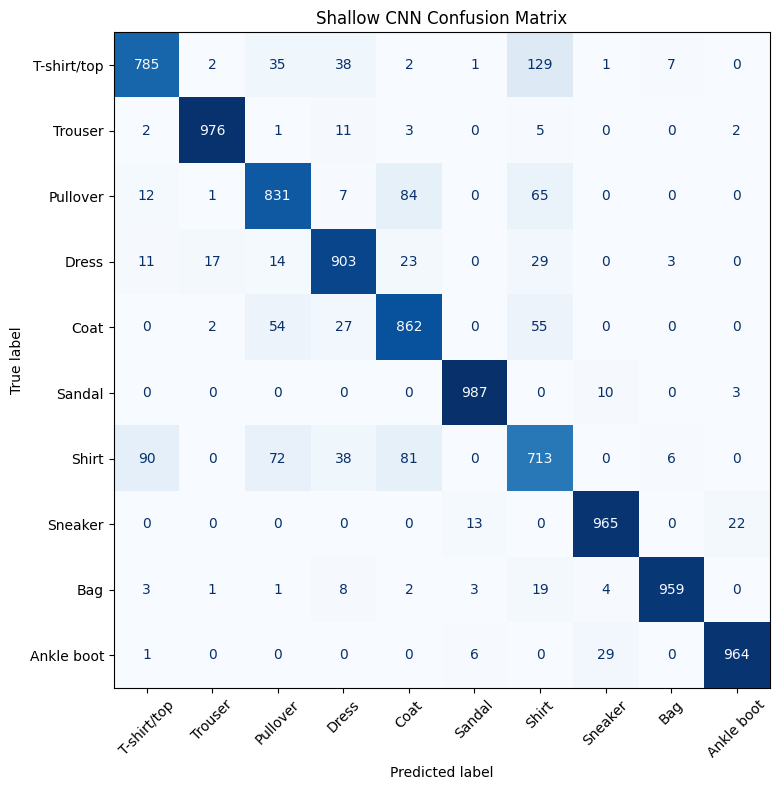

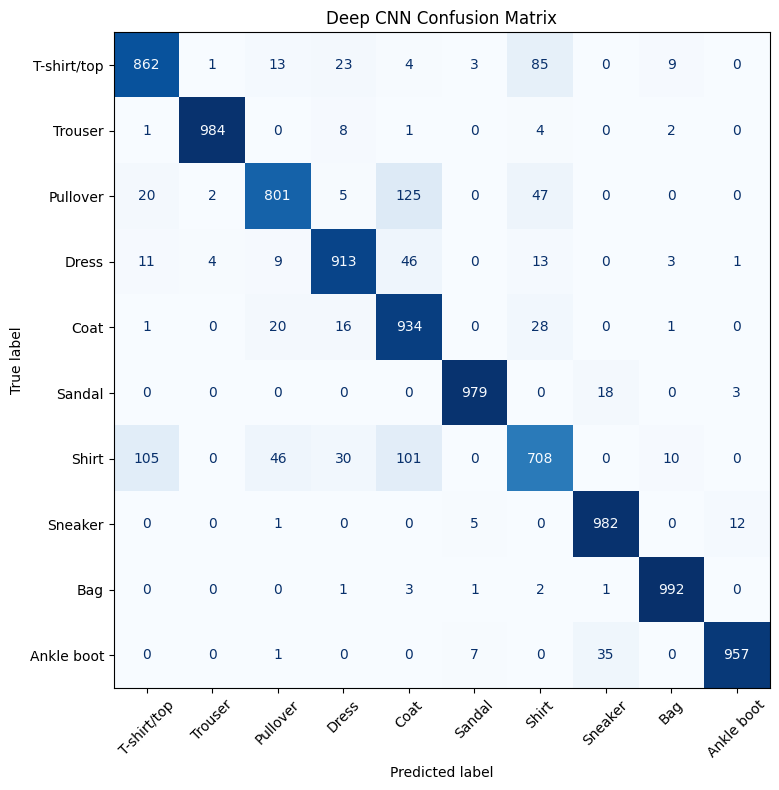

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion(model_name, predictions):
    cm = confusion_matrix(y_test, predictions)
    fig, ax = plt.subplots(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap='Blues', xticks_rotation=45, colorbar=False)
    plt.title(f"{model_name} Confusion Matrix")
    plt.tight_layout()
    plt.show()

plot_confusion("Shallow CNN", shallow_pred)
plot_confusion("Deep CNN", deep_pred)

### Which classes were easiest to classify?
The classes with distinctive shapes. In both models the top performers were Sandal, Trouser, Sneaker, Bag, and Ankle boot, all scoring in the 950s–980s out of 1,000. For example, the deep CNN got Bag 992, Trouser 984, Sneaker 982, and Sandal 979 correct. These items have unique silhouettes that don't overlap with anything else, so both models classify them almost perfectly.

### Which classes were most commonly confused?
The upper-body garments — Shirt, T-shirt/top, Pullover, and Coat — which share similar outlines. Shirt was by far the hardest class (only 713 correct in the shallow model, 708 in the deep), being mistaken mainly for T-shirt/top, Coat, and Pullover. Other big confusions: T-shirt/top → Shirt (129 in shallow), and Pullover ↔ Coat. The footwear group had only minor mixing (Ankle boot ↔ Sneaker).

### Did the deep CNN reduce confusion between similar-looking classes?
Only partly — the result is mixed, which is worth stating honestly. The deep CNN clearly improved some classes: T-shirt/top rose from 785 to 862 correct, and its T-shirt→Shirt confusion dropped from 129 to 85; Coat improved from 862 to 934, with Coat→Pullover confusion falling from 54 to 20. But it did not fix the hardest problem — Shirt stayed essentially flat (713 → 708), and Shirt→T-shirt and Shirt→Coat confusion actually rose slightly. Pullover even got a little worse (831 → 801 correct), with more Pullover→Coat errors (84 → 125). So the deep CNN reduced confusion for several similar-looking pairs and lifted overall accuracy, but the core Shirt-vs-other-tops ambiguity remained — that boundary is genuinely hard because even humans struggle to tell these garments apart at 28×28 resolution.

## Part 6: Final Comparative Conclusion

### Which model was more accurate?
The deep CNN. It achieved 91.11% test accuracy versus the shallow model's 89.45%, along with higher validation accuracy (91.47% vs 89.83%). The deep model also generalized better, with a smaller training–validation gap (≈2.8% vs ≈4.1%), helped by its Dropout layer. Its confusion matrix showed improvements on several classes, notably T-shirt/top and Coat. However, both models struggled equally with the Shirt class (around 71% correct), since shirts, t-shirts, pullovers, and coats look very similar at 28×28 resolution — a limit the extra depth could not overcome.

### Which model was more efficient? 
The shallow CNN, decisively. It trained in 29.68 seconds compared to 298.54 seconds for the deep model — roughly 10× faster — while using about a third of the parameters. For a gain of only ~1.7 percentage points in accuracy, the deep model demanded an order of magnitude more training time and far more memory.

### Which model would you recommend for Fashion-MNIST? 
For this dataset, the shallow CNN is the more practical recommendation. It delivers nearly the same accuracy at a fraction of the computational cost, which matters when efficiency, speed, or limited hardware are concerns. The deep CNN is the better choice only when squeezing out every last point of accuracy is the priority and training resources are not a constraint.

### What did you learn from this comparative study?
Adding depth to a CNN improves accuracy and generalization, but with clear diminishing returns on a simple, low-resolution dataset like Fashion-MNIST — the gains were small while the costs grew sharply. I also learned that some errors are inherent to the data rather than the model: visually similar classes like Shirt remained difficult regardless of architecture. Most importantly, I learned that "better" depends on context — the right model balances accuracy against efficiency, and a simpler model is often the smarter engineering choice when the accuracy difference is marginal.
